# Oppgave 2k)

# hentet fra kode før

In [7]:
import numpy as np

def matrixToVector(M):
    v = np.zeros(2 * M.size)
    for i, j in np.ndindex(M.shape):
        v[i * M.shape[1] + j] = np.real(M[i, j])
        v[M.size + i * M.shape[1] + j] = np.imag(M[i, j])
    return v

def vectorToMatrix(v):
    M = np.zeros((2, 2), dtype=complex)
    for i, j in np.ndindex(M.shape):
        M[i, j] = v[i * M.shape[1] + j] + 1j * v[M.size + i * M.shape[1] + j]
    return M

def combineVectors(m_1, m_2, m_3, m_4):
    return np.concatenate((m_1, m_2, m_3, m_4))

def seperateVector(v):
    return  np.array_split(v, 4)


#Oppgave c)
def vFromGammaAndOmega(gamma, gammaTilde, omega, omegaTilde):
    return combineVectors(matrixToVector(gamma), matrixToVector(gammaTilde), matrixToVector(omega), matrixToVector(omegaTilde))

def GammaAndOmegaFromv(v):
    m_1, m_2, m_3, m_4 = seperateVector(v) 
    return vectorToMatrix(m_1), vectorToMatrix(m_2), vectorToMatrix(m_3), vectorToMatrix(m_4)


delta = 0.01

def derivative(v, eps):

    # Converting to vector because it is easier to work with
    gamma, gammaTilde, omega, omegaTilde = GammaAndOmegaFromv(v)

    # Defining necessary matrices
    I = np.eye(2)
    N = np.linalg.inv(I - (gamma @ gammaTilde))
    Ntilde = np.linalg.inv(I - (gammaTilde @ gamma))

    # Using Usadel equations to define derivatives 
    dgamma = omega
    dgammaTilde = omegaTilde
    domega = -2*1j * (eps + 1j*delta)*gamma - 2* omega @ Ntilde @ gammaTilde @ omega   
    domegaTilde = -2*1j * (eps + 1j*delta)*gammaTilde - 2* omegaTilde @ N  @ gamma @ omegaTilde

    return vFromGammaAndOmega(dgamma, dgammaTilde, domega, domegaTilde) 


def derivativeForPosition(x, vec):
    vecDerivative = np.zeros_like(vec)
    for i in range(x.size):
        vecDerivative[:, i] = derivative(vec[:, i], epsilon)
    return vecDerivative

def boundaryConditionsNormal(vLeft, vRight):
    zeta = 3
    l = 1
    gammaL = 0
    gammaTildeL = 0
    gammaR = 0
    gammaTildeR = 0

    gamma0, gammaTilde0, omega0, omegaTilde0 = GammaAndOmegaFromv(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = GammaAndOmegaFromv(vRight)


    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    #boundary condition matrices
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    return vFromGammaAndOmega(bcl1, bcl2, bcr1, bcr2)

def boundaryConditionsSuperconductur(vLeft, vRight):
    zeta = 3
    delta = 0.01

    s = np.sinh(np.arctanh(1/(epsilon+delta*1j)))
    c = np.cosh(np.arctanh(1/(epsilon + delta*1j)))

    gammaL = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiL)
    gammaTildeL = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiL)
    gammaR = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiR)
    gammaTildeR = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiR)

    gamma0, gammaTilde0, omega0, omegaTilde0 = GammaAndOmegaFromv(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = GammaAndOmegaFromv(vRight)


    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    #boundary condition matrices
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    return vFromGammaAndOmega(bcl1, bcl2, bcr1, bcr2)

def densityOfStates(x, vec):
     rho3 = np.block([[np.eye(2), np.zeros((2, 2))],
                [np.zeros((2, 2)), -np.eye(2)]])

     if len(x) == 1:
          gamma, gammaTilde, _, _ = GammaAndOmegaFromv(vec)
          I = np.eye(2)
          N = np.linalg.inv(I - (gamma @ gammaTilde))
          NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
          g = np.block([[(2*N - I), (2*N @ gamma)],
          [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])
          dos = (np.real(np.trace(rho3 @ g))/4)
     else:
          dos = []
          for i in range(len(x)):
               gamma, gammaTilde, omega, omegaTilde = GammaAndOmegaFromv(vec[:,i])
               I = np.eye(2)
               N = np.linalg.inv(I - (gamma @ gammaTilde))
               NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
               g = np.block([[(2*N - I), (2*N @ gamma)],
               [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])
               dos.append(np.real(np.trace(rho3 @ g))/4)
     
     return dos

# k)

Processing l: 100%|██████████| 3/3 [28:30<00:00, 570.03s/it]


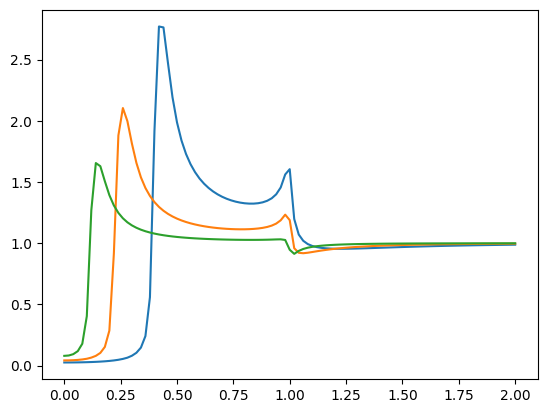

In [ ]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

ls = [0.5, 1, 2]
m = 100

for l in tqdm(ls, "Processing l"):
    x = np.linspace(0, l, m)
    y = np.zeros((32,m))
    epsilons = np.linspace(2, 0, 101)
    vLeft, vRight = np.zeros(32), np.zeros(32)

    DOS_values = []
    for epsilon in tqdm(epsilons, desc="Processing epsilons"):
        sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductur, x, y)
        DOS = densityOfStates([l/2], sol.sol(l/2))
        DOS_values.append(DOS)
        y = sol.sol(x)

    plt.plot(epsilons, DOS_values, label=f"Epsilon: {epsilon}")

plt.title("")
plt.grid(True)
plt.legend()
plt.show()
    

Processing epsilons: 100%|██████████| 101/101 [08:25<00:00,  5.00s/it]


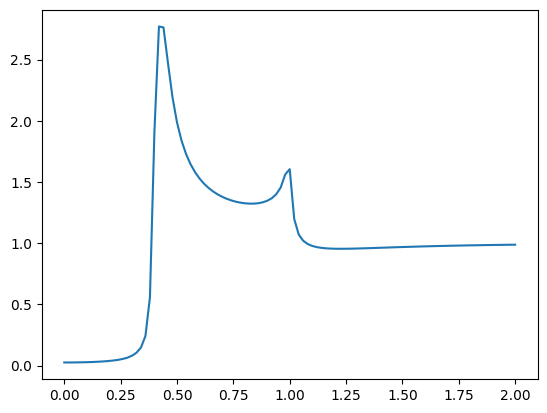

In [ ]:
l = 0.5
m = 100

x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.linspace(2, 0, 101)
vLeft, vRight = np.zeros(32), np.zeros(32)

DOS_values = []
for epsilon in tqdm(epsilons, desc="Processing epsilons"):
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductur, x, y)
    DOS = densityOfStates([l/2], sol.sol(l/2))
    DOS_values.append(DOS)
    y = sol.sol(x)

plt.plot(epsilons, DOS_values)
plt.show()

Processing epsilons: 100%|██████████| 101/101 [08:27<00:00,  5.03s/it]


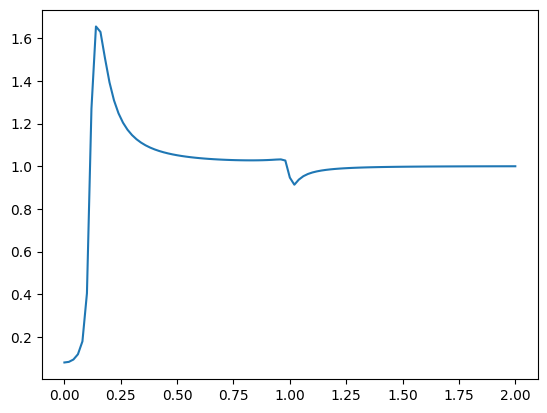

In [ ]:
l = 2
m = 100

x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.linspace(2, 0, 101)
vLeft, vRight = np.zeros(32), np.zeros(32)

DOS_values = []
for epsilon in tqdm(epsilons, desc="Processing epsilons"):
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductur, x, y)
    DOS = densityOfStates([l/2], sol.sol(l/2))
    DOS_values.append(DOS)
    y = sol.sol(x)

plt.plot(epsilons, DOS_values)
plt.show()